### KNN회귀(Regression)

#### 생선의 길이를 사용하여 무게를 예측

In [1]:
import numpy as np

In [2]:
fish_length = np.array(
  [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0, 
    21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5, 
    22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5, 
    27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0, 
    36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0, 
    40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
  )
fish_weight = np.array(
  [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 
    110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 
    130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 
    197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 
    514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 
    820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 
    1000.0, 1000.0]
  )

### 길이와 무게를 산포도로 표현

In [3]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

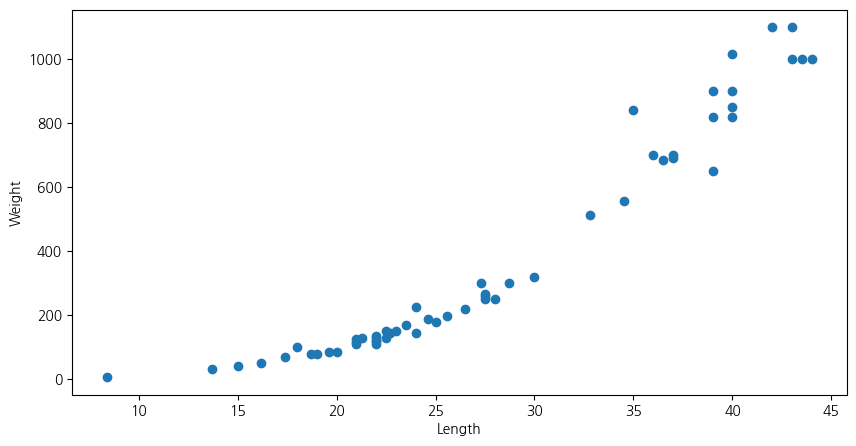

In [4]:
plt.figure(figsize=(10,5))

plt.scatter(
  fish_length,
  fish_weight,
)
plt.xlabel("Length")
plt.ylabel("Weight")

plt.show()

### Train Set과 Test Set 분리

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
train_input, test_input, train_target, test_target = \
  train_test_split(
    fish_length,
    fish_weight,
    random_state=42,
    test_size=0.2,
    
  )
## 회귀는 stratify를 하면 안된다

In [7]:
# 확인
print(train_input.shape, test_input.shape)
print(train_target.shape, test_target.shape)

(44,) (12,)
(44,) (12,)


In [8]:
train_input

array([28. , 27.3, 19.6, 22. , 18.7, 17.4, 36. , 25. , 40. , 39. , 43. ,
       22. , 20. , 22. , 24. , 27.5, 43. , 40. , 24. , 21. , 27.5, 40. ,
       32.8, 26.5, 36.5, 13.7, 22.7, 15. , 37. , 35. , 28.7, 23.5, 39. ,
       21. , 23. , 22. , 44. , 22.5, 19. , 37. , 22. , 25.6, 42. , 34.5])

In [9]:
# 1열로 구성된 배열로 재구성
train_input = train_input.reshape(-1,1)
test_input = test_input.reshape(-1,1)

print(train_input.shape, test_input.shape)

(44, 1) (12, 1)


### 회귀 모델 사용

In [10]:
from sklearn.neighbors import KNeighborsRegressor

In [11]:
knr = KNeighborsRegressor().fit(train_input, train_target)

In [12]:
print(knr.score(test_input, test_target))

0.9932626838364674


### 결정계수($ R^2$): 평균 절대값 오차
: R^2 = 1 - ((Target - 예측값)^2의 합  / (Target - 평균)^2의 합)

In [13]:
from sklearn.metrics import mean_absolute_error

In [14]:
# score만 신뢰하지 말고 꼭 오차값을 확인하자

# 테스트 세트에 대한 예측
test_pred = knr.predict(test_input)

# 평균 절대값 오차에 적용
mae = mean_absolute_error(test_target, test_pred)
print(mae)
print(np.sqrt(mae))

21.433333333333337
4.629614814791111


### 과대적합(Overfitting)과 과소적합(Underfitting)

In [15]:
# score 측정
print(knr.score(train_input, train_target))
print(knr.score(test_input, test_target))

0.9699886106745992
0.9932626838364674


> 과소적합이 판단되어 새로운 model이 필요함 (현재 KNN의 기본값이 5를 사용)

In [16]:
### 이웃의 갯수를 3으로 변경하여 Train과 Test점수를 출력하자

# knr = KNeighborsRegressor(n_neighbors=3).fit(train_input, train_target)

knr.n_neighbors = 3

knr.fit(train_input, train_target)

print(knr.score(train_input, train_target))
print(knr.score(test_input, test_target))

0.9803764248982696
0.9761346952012298


In [17]:
knr.n_neighbors = 10

knr.fit(train_input, train_target)

print(knr.score(train_input, train_target))
print(knr.score(test_input, test_target))

0.9618008489958115
0.980567082352166


### 이웃의 갯수 조절로 확인

K ==> 1
Train Score : 0.9853718805456808
Test Score : 0.9924792174142072


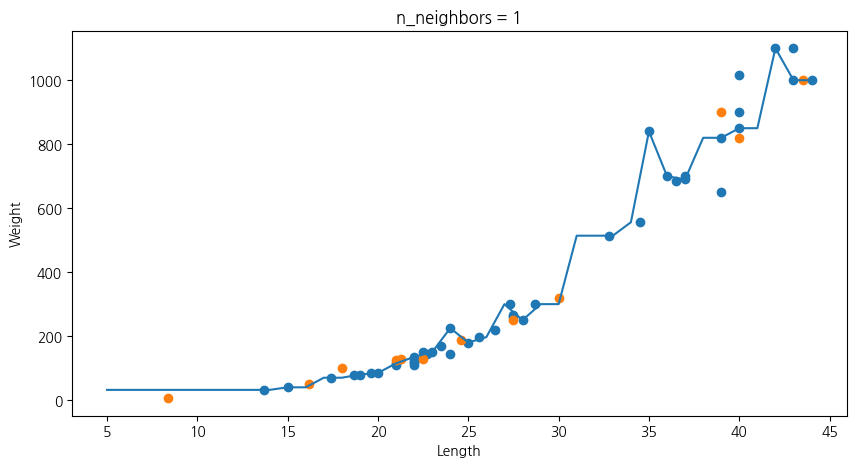

K ==> 3
Train Score : 0.9803764248982696
Test Score : 0.9761346952012298


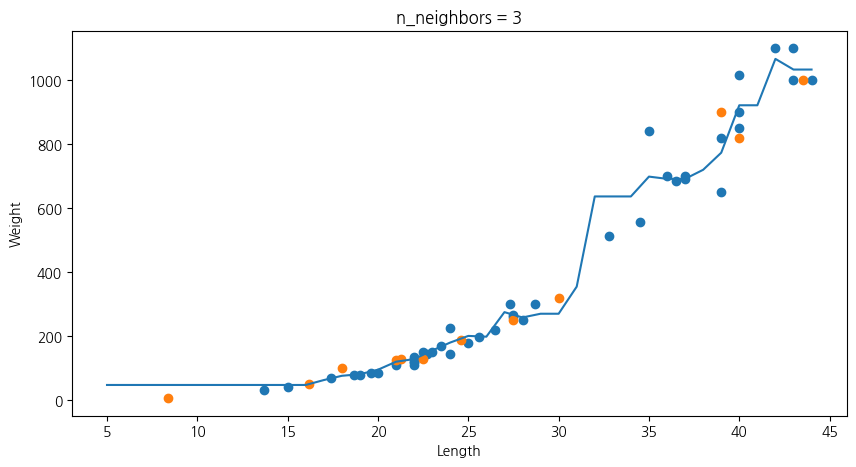

K ==> 5
Train Score : 0.9699886106745992
Test Score : 0.9932626838364674


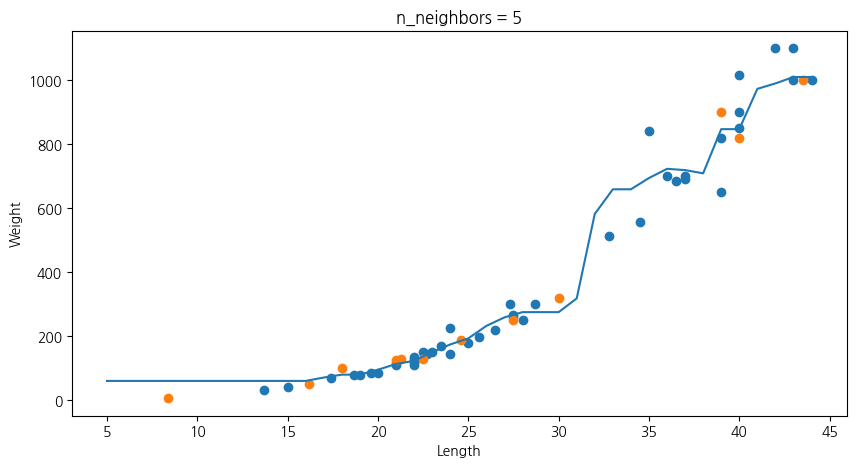

K ==> 10
Train Score : 0.9618008489958115
Test Score : 0.980567082352166


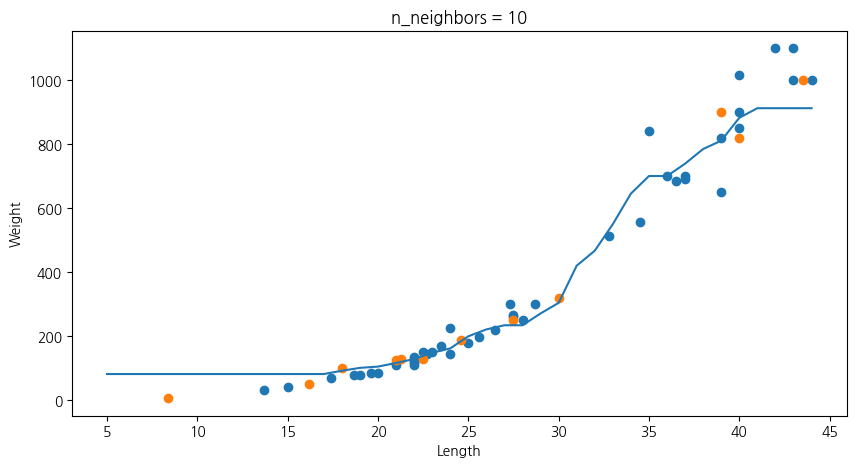

In [ ]:
knr = KNeighborsRegressor()

# 5에서 45까지 좌표
x = np.arange(5,45).reshape(-1,1)


# n_neighbors = 1, 3, 5, 10일때 예측 결과 그래프
for n in [1,3,5,10]:
  knr.n_neighbors = n
  knr.fit(train_input, train_target)
  print("K ==>", n)
  print("Train Score :", knr.score(train_input, train_target))
  print("Test Score :", knr.score(test_input, test_target))


# 지정한 범위 x에 대한 예측 구하기
  pred = knr.predict(x)


# 훈련세트와 검증세트의 예츠 결과 그리기
  plt.figure(figsize=(10,5))

  plt.scatter(train_input,train_target)
  plt.scatter(test_input,test_target)
  plt.plot(x, pred)
  plt.title(f'n_neighbors = {n}')
  plt.xlabel("Length")
  plt.ylabel("Weight")

  plt.show()


### KNN Regression Model
: 이웃의 갯수를 3으로 정한다

In [19]:
knr = KNeighborsRegressor(n_neighbors=3)
knr.fit(train_input, train_target)

KNeighborsRegressor(n_neighbors=3)

### 길이가 50CM인 생선의 무게 예측

In [20]:
knr.predict([[50]])

array([1033.33333333])

### 기존 데이터로 무게 확인

In [21]:
for i, v in list(enumerate(train_target)):
    if v == train_target.max():
        print(train_input[i], v)

[43.] 1100.0
[42.] 1100.0


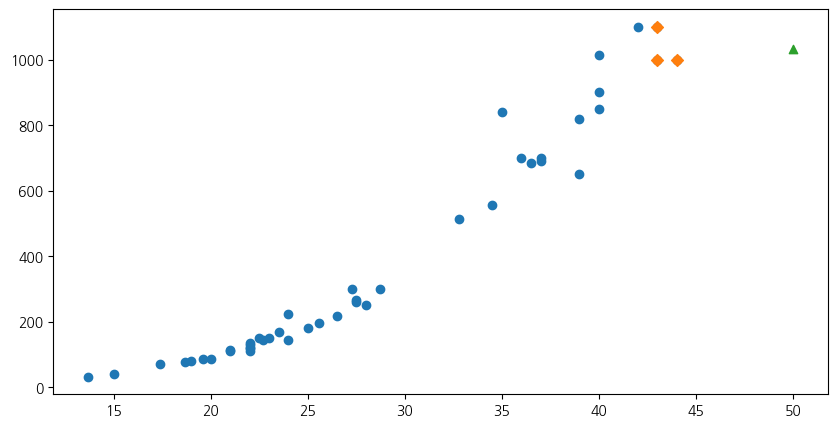

In [22]:
# 50cm 생선의 이웃
distance, indexes = knr.kneighbors([[50]])

plt.figure(figsize=(10,5))

plt.scatter(train_input, train_target)
plt.scatter(train_input[indexes], train_target[indexes], marker='D')
plt.scatter(50, 1033, marker='^')

In [23]:
# 이웃들의 평균
np.mean(train_target[indexes])

1033.3333333333333

#### 길이가 100인 생선의 무게

In [24]:
knr.predict([[100]])

array([1033.33333333])

---
### 선형회귀(Linear Regression)
: 직선이나 곡선의 함수식(Y=aX+b)을 이용하여 구하는 방식으로 로지스틱 회귀분석이나 인공신경망의 기초가 되었다.

In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
lr = LinearRegression()
lr.fit(train_input, train_target)

LinearRegression()

In [27]:
lr.predict([[50]])

array([1238.3175398])

In [28]:
# Y=aX+b에서 기울기와 절편값을 출력(Deep Learning에서는 Weight와 Bias)
print(lr.coef_, lr.intercept_)

[39.05365447] -714.3651839448922


In [29]:
39.05365447 * 50 - 714.3651839448922

1238.3175395551075

### 산점도 그려보기

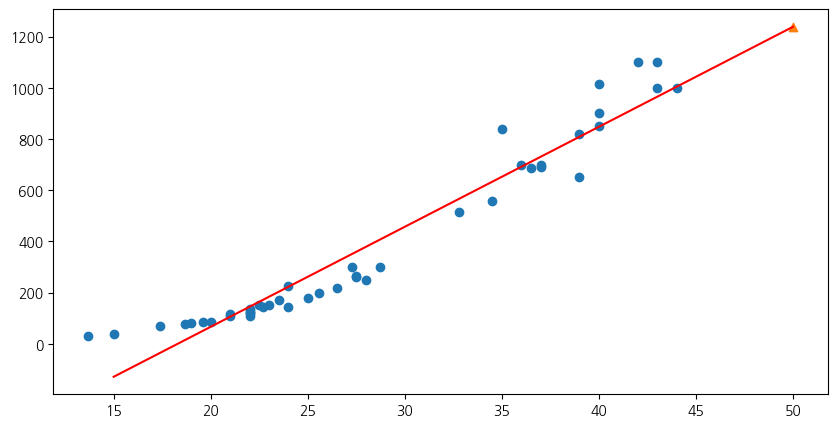

In [30]:
plt.figure(figsize=(10,5))

plt.scatter(train_input, train_target)


# 15에서 50까지의 1차 방정식 그래프를 그립니다.
plt.plot(
  [15,50],
  [15 * lr.coef_ + lr.intercept_, 50*lr.coef_+lr.intercept_], # 회귀선, 평균선, 중심선
  c='red'
)

# 50cm 생선
plt.scatter(50,1238,marker='^')


plt.show()

> 산점도의 회귀선을 보니 길이가 작아지면 무게가 음수가 발생할 수 있다.  
절편이 음수이다

#### 과대적합과 과소적합 확인

In [31]:
print(lr.score(train_input, train_target))
print(lr.score(test_input, test_target))

0.9363463656327585
0.8359630155975616


---
### 다항 회귀
Y = aX + b -> Y = $a X^2 $ + bX + C
- 항이 여러개 있고 Feature가 하나인 것을 의미한다
- Feature 가 여러개인 회귀는 다중회귀 라고 한다.

In [32]:
# Feature를 제곱한 Column을 생성하여 기존 컬럼에 붙인다.
train_poly = np.column_stack((train_input**2, train_input))
test_poly = np.column_stack((test_input**2, test_input))

In [33]:
print(train_poly.shape, test_poly.shape)

(44, 2) (12, 2)


In [34]:
lr = LinearRegression()
lr.fit(train_poly, train_target)

LinearRegression()

In [35]:
print(lr.predict([[50**2,50]]))

[1579.0440311]


In [36]:
# 기울기와 절편
print(lr.coef_,lr.intercept_)

[  1.03238928 -22.63525541] 129.83360652841537


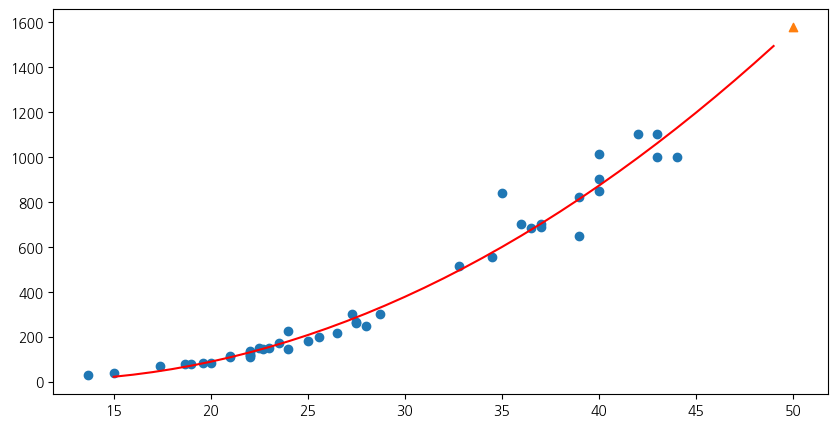

In [37]:
plt.figure(figsize=(10,5))

plt.scatter(train_input, train_target)


# 15에서 50까지의 2차 방정식 그래프를 그립니다.
point = np.arange(15,50)
plt.plot(
    point,
    1.03 * point**2 - 22.64 * point + 129.8,
    c='red'
)

# 50cm 생선
plt.scatter(50,1579,marker='^')


plt.show()

In [38]:
### 과대적합과 과소 적합 확인

print(lr.score(train_poly, train_target))
print(lr.score(test_poly, test_target))

0.9701854947585989
0.9801885585527478
